In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("anonymized_marks.csv")

# Preview
print(df)

      Student  Marks
0    Student1   14.5
1    Student2    1.0
2    Student3    5.0
3    Student4    5.0
4    Student5   13.0
5    Student6    3.0
6    Student7    0.0
7    Student8    0.5
8    Student9    4.0
9   Student10    6.5
10  Student11    6.0
11  Student12    9.5
12  Student13    6.0
13  Student14    2.0
14  Student15    1.0
15  Student16    1.5
16  Student17    4.0
17  Student18    9.0
18  Student19   12.5
19  Student20   11.5
20  Student21    2.5
21  Student22    5.5
22  Student23    5.5
23  Student24    2.5
24  Student25   12.0
25  Student26   17.5
26  Student27    4.0
27  Student28   11.0
28  Student29   14.0
29  Student30    4.5
30  Student31   11.5
31  Student32    4.5
32  Student33   15.0
33  Student34   10.0
34  Student35   15.5
35  Student36   15.0
36  Student37   14.5
37  Student38    8.0
38  Student39   13.5
39  Student40   16.0
40  Student41    9.5
41  Student42   12.5
42  Student43   11.5
43  Student44   10.5
44  Student45   14.5
45  Student46   11.5
46  Student47

In [22]:
# Basic info
print(df.info())

# Summary statistics
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Student  59 non-null     object 
 1   Marks    59 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.1+ KB
None
           Marks
count  59.000000
mean    7.881356
std     5.032942
min     0.000000
25%     4.000000
50%     6.000000
75%    12.250000
max    17.500000


In [23]:
# Check missing values
print(df.isnull().sum())

# If any missing values (not needed here but good practice)
df = df.dropna()

Student    0
Marks      0
dtype: int64


In [24]:
mean_marks = df["Marks"].mean()
median_marks = df["Marks"].median()
std_marks = df["Marks"].std()

print("Mean:", mean_marks)
print("Median:", median_marks)
print("Std Dev:", std_marks)

Mean: 7.88135593220339
Median: 6.0
Std Dev: 5.03294232776179


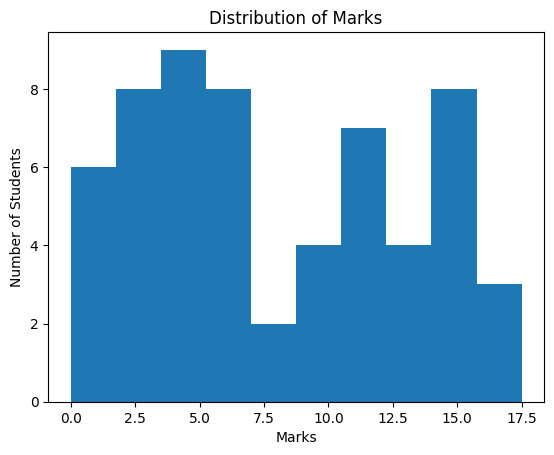

In [25]:
import matplotlib.pyplot as plt

plt.hist(df["Marks"], bins=10)
plt.title("Distribution of Marks")
plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.show()

In [26]:
# Top 5 students
top_students = df.sort_values(by="Marks", ascending=False).head()
print(top_students)

# Bottom 5 students
bottom_students = df.sort_values(by="Marks").head()
print(bottom_students)

      Student  Marks
25  Student26   17.5
46  Student47   16.0
39  Student40   16.0
34  Student35   15.5
35  Student36   15.0
      Student  Marks
6    Student7    0.0
7    Student8    0.5
1    Student2    1.0
14  Student15    1.0
15  Student16    1.5


In [31]:
def grade(marks):
    if marks >= 18:
        return "A+"
    elif marks >= 15:
        return "A"
    elif marks >= 13:
        return "B+"
    elif marks >= 10:
        return "B"
    elif marks >= 8:
        return "C+"
    elif marks >= 5:
        return "C"
    else:
        return "D"

# Apply grading
df["Grade"] = df["Marks"].apply(grade)
print(df)

      Student  Marks Grade
0    Student1   14.5    B+
1    Student2    1.0     D
2    Student3    5.0     C
3    Student4    5.0     C
4    Student5   13.0    B+
5    Student6    3.0     D
6    Student7    0.0     D
7    Student8    0.5     D
8    Student9    4.0     D
9   Student10    6.5     C
10  Student11    6.0     C
11  Student12    9.5    C+
12  Student13    6.0     C
13  Student14    2.0     D
14  Student15    1.0     D
15  Student16    1.5     D
16  Student17    4.0     D
17  Student18    9.0    C+
18  Student19   12.5     B
19  Student20   11.5     B
20  Student21    2.5     D
21  Student22    5.5     C
22  Student23    5.5     C
23  Student24    2.5     D
24  Student25   12.0     B
25  Student26   17.5     A
26  Student27    4.0     D
27  Student28   11.0     B
28  Student29   14.0    B+
29  Student30    4.5     D
30  Student31   11.5     B
31  Student32    4.5     D
32  Student33   15.0     A
33  Student34   10.0     B
34  Student35   15.5     A
35  Student36   15.0     A
3

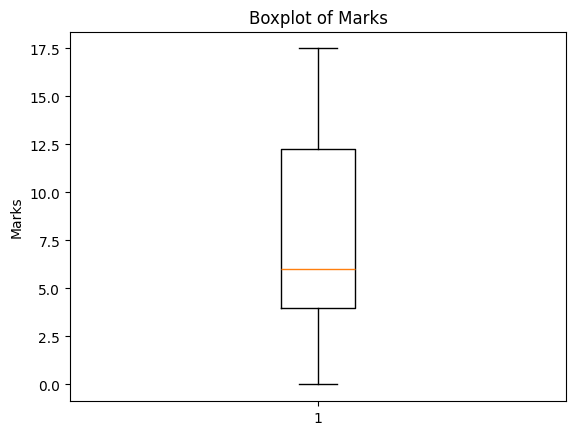

In [33]:
plt.boxplot(df["Marks"])
plt.title("Boxplot of Marks")
plt.ylabel("Marks")
plt.show()


In [35]:
Q1 = df["Marks"].quantile(0.25)
Q3 = df["Marks"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Marks"] < Q1 - 1.5*IQR) | (df["Marks"] > Q3 + 1.5*IQR)]

print("Outliers:")
print(outliers)

Outliers:
Empty DataFrame
Columns: [Student, Marks, Grade]
Index: []


In [37]:
df.to_csv("processed_marks.csv", index=False)

In [40]:
print("Average Marks:", df["Marks"].mean())
print("Median Marks:", df["Marks"].median())
print("Highest Marks:", df["Marks"].max())
print("Lowest Marks:", df["Marks"].min())

Average Marks: 7.88135593220339
Median Marks: 6.0
Highest Marks: 17.5
Lowest Marks: 0.0


In [42]:
print("Variance:", df["Marks"].var())
print("Standard Deviation:", df["Marks"].std())

Variance: 25.33050847457627
Standard Deviation: 5.03294232776179


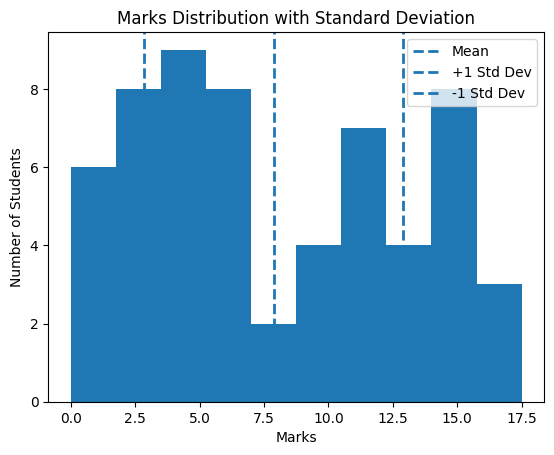

In [44]:
import matplotlib.pyplot as plt

mean = df["Marks"].mean()
std = df["Marks"].std()

# Histogram
plt.hist(df["Marks"], bins=10)

# Mean line
plt.axvline(mean, linestyle='dashed', linewidth=2, label='Mean')

# Std deviation lines
plt.axvline(mean + std, linestyle='dashed', linewidth=2, label='+1 Std Dev')
plt.axvline(mean - std, linestyle='dashed', linewidth=2, label='-1 Std Dev')

plt.title("Marks Distribution with Standard Deviation")
plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.legend()

plt.show()

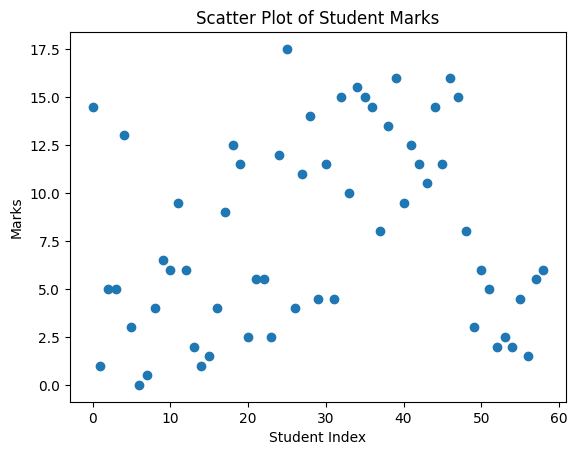

In [46]:
plt.scatter(df.index, df["Marks"])

plt.title("Scatter Plot of Student Marks")
plt.xlabel("Student Index")
plt.ylabel("Marks")

plt.show()

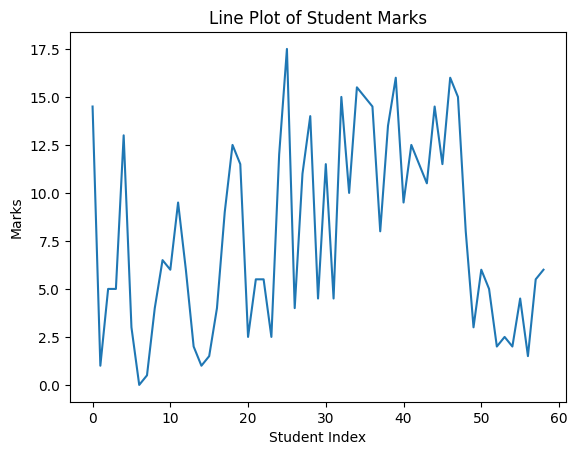

In [52]:
plt.plot(df.index, df["Marks"])

plt.title("Line Plot of Student Marks")
plt.xlabel("Student Index")
plt.ylabel("Marks")

plt.show()